# Segmentation sample/not sample

In this notebook, all 18 SAXS samples are segmented, removing all non-sample data


### Imports & Setting up the notebook

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from scipy.ndimage import binary_opening, binary_fill_holes, label

### Functions

#### 1. Load the data and inspect

In [145]:
def load_and_inspect(file_path):
    df_import = pd.read_csv(file_path)
    df = df_import.dropna(subset=['total SAXS intensity']).copy()
    
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=df, x='x', y='y', hue='total SAXS intensity', palette='viridis', edgecolor='none', s=25, marker='s')
    plt.title(f'Raw Input: {file_path.split("/")[-1]}', fontsize=14)
    plt.axis('equal')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    return df

#### 2. Segment the data

In [53]:
def apply_segmentation(df, method='kmeans', manual_thresh=0.6):
    x_grid = (df['x'] - df['x'].min()).astype(int)
    y_grid = (df['y'] - df['y'].min()).astype(int)
    grid = np.zeros((y_grid.max() + 1, x_grid.max() + 1))
    
    if method == 'kmeans':
        intensities = df['total SAXS intensity'].values.reshape(-1, 1)
        kmeans_seg = KMeans(n_clusters=2, random_state=42, n_init=10).fit(intensities)
        bright_cluster = np.argmax(kmeans_seg.cluster_centers_)
        foreground_mask = (kmeans_seg.labels_ == bright_cluster).astype(int)
    else:
        foreground_mask = (df['total SAXS intensity'] > manual_thresh).astype(int)
        
    grid[y_grid, x_grid] = foreground_mask
    
    grid_disconnected = binary_opening(grid, structure=np.ones((3, 3)))
    labeled_grid, num_features = label(grid_disconnected)
    sizes = np.bincount(labeled_grid.ravel())
    if len(sizes) > 1:
        sizes[0] = 0 
        clean_mask = binary_fill_holes(labeled_grid == sizes.argmax())
    else:
        clean_mask = grid
        
    df_copy = df.copy()
    df_copy['is_real_tissue'] = clean_mask[y_grid, x_grid]
    return df_copy[df_copy['is_real_tissue'] == 1].copy()

#### 3. Plot Comparison

In [203]:
def plot_comparison(df_raw, df_clean, title, sample_id):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    sns.scatterplot(data=df_raw, x='x', y='y', hue='total SAXS intensity', palette='viridis', edgecolor='none', s=45, marker='s', ax=axes[0])
    axes[0].set_title('Raw Input', fontsize=14)
    axes[0].axis('equal')
    axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    sns.scatterplot(data=df_clean, x='x', y='y', hue='total SAXS intensity', palette='viridis', edgecolor='none', s=45, marker='s', ax=axes[1])
    axes[1].set_title(f'Cleaned ({title})', fontsize=14)
    axes[1].axis('equal')
    axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.savefig(f"Data-cleaned/{sample_id} IQ_plot.png", dpi=300, bbox_inches='tight')
    plt.show()

### Segmenting

In [216]:
# Sample choosen
current_sample_id = '692823'
current_wound_day = 14

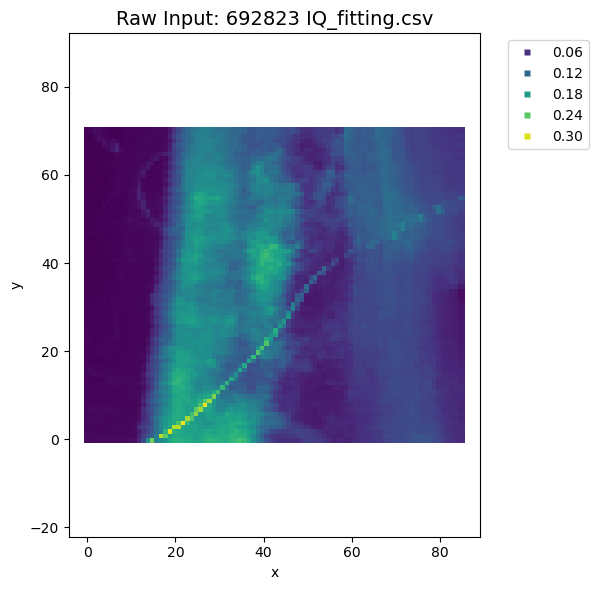

count    6106.000000
mean        0.087811
std         0.051698
min         0.016547
25%         0.048407
50%         0.080277
75%         0.123183
max         0.318668
Name: total SAXS intensity, dtype: float64


In [217]:
# load
file_to_test = f'Data/{current_sample_id} IQ_fitting.csv'
df_raw = load_and_inspect(file_to_test)
print(df_raw['total SAXS intensity'].describe())

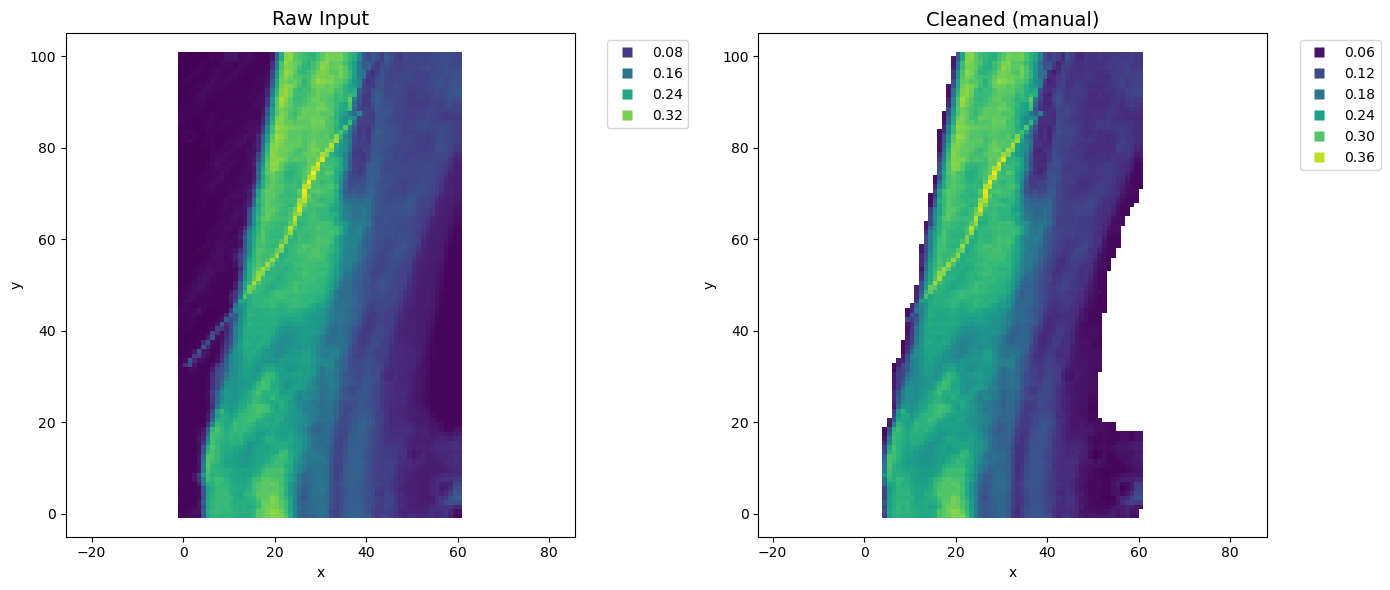

In [214]:
current_method = 'manual'  # either 'kmeans' or 'manual'
current_thresh = 0.05

# Run the segmentation
df_clean = apply_segmentation(df_raw, method=current_method, manual_thresh=current_thresh)

# Check the side-by-side result
plot_comparison(df_raw, df_clean, title=current_method, sample_id=current_sample_id)

In [215]:
# Stamp the manifest info
df_clean['sample_id'] = current_sample_id
df_clean['wound_day'] = current_wound_day

# Save
save_path = f"Data-cleaned/{current_sample_id} IQ_cleaned.csv"
df_clean.to_csv(save_path, index=False)
print(f"Saved cleanly to {save_path}")

Saved cleanly to Data-cleaned/692798 IQ_cleaned.csv
